In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [2]))
print('using GPU %s' % ','.join(map(str, [2])))

import torch
import torch.optim as optim
from thop import profile, clever_format

import csv
import time
import numpy as np
import json
from datetime import datetime
import matplotlib.pyplot as plt
plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe, data_reader
from loadData.split_data import HyperX
from loadData.dataAugmentation import DataAugmentationDINO

from utils import util, KNN, SVM, trainer, tester
from models import model, vision_transformer, automaticWeightedLoss, vitgcn_model

using GPU 2


In [2]:
args = opt.get_args()
# args.dataset_name = "IndianPines"
# args.dataset_name = "PaviaU"
# args.dataset_name = "LongKou"
# args.dataset_name = "HanChuan"
# args.dataset_name = "HongHu"
# args.dataset_name = "PaviaC"
args.dataset_name = "Dioni"
args.backbone = "vit"
args.local_crops_number = 0
args.patch_size = 25
args.randomCrop = 23
args.components = 3
args.split_type = "disjoint"
args.lambda_contra = 0
args.lambda_super = 1
args.awl = True

args.result_dir = os.path.join("/home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/" + 
                    datetime.now().strftime("%m-%d-%H-%M-vit_D_super"))
# args.result_dir = "/home/liuquanwei/code/DMVL_joint_multiCrop/results/07-30-11-28-joint_multiCrop-ablation"
print(args.result_dir)

# 加载已有权重路径
# args.result_dir = "/home/liuquanwei/code/DMVL_joint_MNDIS/results_final/08-12-11-01-vit_D"
if not os.path.exists(args.result_dir):
    os.mkdir(args.result_dir)
with open(args.result_dir + '/args.json', 'w') as fid:
    json.dump(args.__dict__, fid, indent=2)

/home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/10-18-14-24-vit_D_super


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, _, _ = data_pipe.get_data(args)
transform = DataAugmentationDINO(args.randomCrop)

train_dataset = HyperX(img1, img2, train_gt, transform=transform, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)

args.train_ratio = 0.5
img1, img2, train_gt, test_gt, _ = data_pipe.get_data(args)
memory_dataset = HyperX(img1, img2, train_gt, transform=None, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)
test_dataset = HyperX(img1, img2, test_gt, transform=None, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)

memory_loader = torch.utils.data.DataLoader(memory_dataset,batch_size=args.batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=args.batch_size,shuffle=False)

class_num = np.max(train_gt)
print(class_num, train_gt.shape), len(train_loader.dataset)

halving_line 88
(274, 1400, 176) (274, 1400, 3) (274, 1400, 3) (274, 1400)
split_type:  disjoint 
train_ratio:  1
(274, 1400) (274, 1400)
halving_line 88
(274, 1400, 176) (274, 1400, 3) (274, 1400, 3) (274, 1400)
split_type:  disjoint 
train_ratio:  0.5
(274, 1400) (274, 1400)
12 (274, 1400)


(None, 20024)

In [4]:
# for x, y, z in train_loader:
#     print("x.shape, y.shape", x[0].shape)

# model

In [5]:
# model setup and optimizer config
# encoder = model.Model_base(args.components).cuda()
encoder = vision_transformer.vit_hsi(args.components, args.randomCrop).cuda()
# encoder = vision_transformer.vit_small(args.components, args.randomCrop).cuda()
contra_head = model.DINOHead(args.feature_dim).cuda()
super_head = model.FDGC_head(args.feature_dim, class_num=class_num).cuda()
awl = automaticWeightedLoss.AutomaticWeightedLoss(2).cuda()
net = util.MultiCropWrapper(encoder).cuda()
# print(model)
flops, params = profile(net, inputs=(torch.randn(1, args.components, 
                                                args.patch_size, args.patch_size).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

# contra_head
flops, params = profile(contra_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

# super_head
flops, params = profile(super_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

criterion = torch.nn.CrossEntropyLoss()
params = list(super_head.parameters()) + list(contra_head.parameters()) + \
                list(net.parameters()) + list(awl.parameters())
optimizer = optim.Adam(params, lr=1e-3, weight_decay=1e-6, amsgrad=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = args.epochs, 
                            eta_min = 1e-8, last_epoch = -1)

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
# Model Params: 520.00K FLOPs: 19.18M
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
# Model Params: 65.66K FLOPs: 66.05K
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <clas

In [6]:
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

# 训练

In [7]:
best_loss = 999
best_acc = 0
train_losses = []
loss_contras = []
loss_supers = []

total_time = time.time()
for epoch in range(epoch_start, args.epochs):
###################################################################->>>>>>>>>
    start_time = time.time()
    train_loss, loss_contra, loss_super, linear_tra,  linear_tea \
                        = trainer.train(epoch, net, contra_head, super_head, awl, 
                                    train_loader, memory_loader, test_loader, optimizer, args)
    train_losses.append(train_loss)
    loss_contras.append(loss_contra)
    loss_supers.append(loss_super)
    scheduler.step()
    train_time = time.time() - start_time
###################################################################<<<<<<<<<<<<-
    
    # # validation
    if epoch % 1 == 0:
        start_time = time.time()
        KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net,memory_loader,test_loader,class_num,train_gt,args)
        Knn_time = time.time() - start_time
        # knn_plot_figure.visulation(net, gt, memory_loader, data_loader, class_num, KNNOA, args)
        
    # if epoch == args.epochs - 1:
    #     start_time = time.time()
    #     SVMCA, SVMOA, SVMAA, SVMkA = SVM_multi.test(net, memory_loader, test_loader, class_num, args)
    #     SVM_time = time.time() - start_time
    #     # svm_plot_figure.visulation(net, gt, memory_loader, data_loader, SVMOA, args)

    #     with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
    #         row=[["epoch", epoch, 
    # ###################################################################->>>>>>>>>
    #             "loss", train_loss, 
    #             "loss_contra", loss_contra,
    #             "loss_super", loss_super,
    #             # "linear_tracc", linear_tra,
    #             "linear_teacc", linear_tea,
    #             "train_time", round(train_time, 2),
    #             '\n',
    # ###################################################################<<<<<<<<<<<<-
    #             # "KNN_CA", np.round(KNNCA, 2),
    #             "KNN_OA", np.round(KNNOA, 2),
    #             "KNN_AA", np.round(KNNAA, 2),
    #             "KNN_KA", np.round(KNNKA, 2),
    #             "KNN_Time", round(Knn_time, 2),
    #             '\n',
    #             "SVM_CA", np.round(SVMCA, 2),
    #             "SVM_OA", np.round(SVMOA, 2),
    #             "SVM_AA", np.round(SVMAA, 2),
    #             "SVM_KA", np.round(SVMkA, 2),
    #             "SVM_time", round(SVM_time, 2)
    #             ]]
    #         write=csv.writer(f)
    #         for i in range(len(row)):
    #             write.writerow(row[i])
    # else:
    with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
###################################################################->>>>>>>>>
            "loss", train_loss, 
            "loss_contra", loss_contra,
            "loss_super", loss_super,
            # "linear_tracc", linear_tra,
            "linear_teacc", linear_tea,
            "train_time", round(train_time, 2),
            '\n',
###################################################################<<<<<<<<<<<<-
            # "KNN_CA", np.round(KNNCA, 2),
            "KNN_OA", np.round(KNNOA, 2),
            "KNN_AA", np.round(KNNAA, 2),
            "KNN_KA", np.round(KNNKA, 2),
            "KNN_Time", round(Knn_time, 2),
            '\n',
            # "SVM_CA", np.round(SVMCA, 2),
            # "SVM_OA", np.round(SVMOA, 2),
            # "SVM_AA", np.round(SVMAA, 2),
            # "SVM_KA", np.round(SVMkA, 2),
            # "SVM_time", round(SVM_time, 2)
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])
####################################################################->>>>>>>>>
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
                "epoch": epoch,
                "base": net.state_dict(),
                "contra_head": contra_head.state_dict(),
                "head": super_head.state_dict(),
                "optimizer": optimizer.state_dict()}, 
                os.path.join(args.result_dir, "joint_model_loss.pth"))
        
    if KNNOA > best_acc:
        best_acc = KNNOA
        torch.save({
                "epoch": epoch,
                "base": net.state_dict(),
                "contra_head": contra_head.state_dict(),
                "head": super_head.state_dict(),
                "optimizer": optimizer.state_dict()}, 
                os.path.join(args.result_dir, "joint_model_oa.pth"))
###################################################################<<<<<<<<<<<<-
total_time = time.time() - total_time

torch.save({
        "epoch": epoch,
        "base": net.state_dict(),
        "contra_head": contra_head.state_dict(),
        "head": super_head.state_dict(),
        "optimizer": optimizer.state_dict()}, 
os.path.join(args.result_dir, "joint_model_last.pth"))

Train Epoch: [0/30] Loss: 1.7327 loss_contra: 0.0000 loss_super: 0.4504 TRA: 76.0043: : 40it [00:34,  1.15it/s]
Train Epoch: [1/30] Loss: 1.4576 loss_contra: 0.0000 loss_super: 0.1957 TRA: 90.4096: : 40it [00:34,  1.14it/s]
Train Epoch: [2/30] Loss: 1.3107 loss_contra: 0.0000 loss_super: 0.1279 TRA: 94.3679: : 40it [00:35,  1.12it/s]
Train Epoch: [3/30] Loss: 1.1782 loss_contra: 0.0000 loss_super: 0.0761 TRA: 97.2922: : 40it [00:35,  1.13it/s]
Train Epoch: [4/30] Loss: 1.0923 loss_contra: 0.0000 loss_super: 0.0435 TRA: 97.5581: : 40it [00:35,  1.13it/s]
Train Epoch: [5/30] Loss: 0.9975 loss_contra: 0.0000 loss_super: 0.0855 TRA: 98.4344: : 40it [00:35,  1.13it/s]
Train Epoch: [6/30] Loss: 0.9251 loss_contra: 0.0000 loss_super: 0.0446 TRA: 98.6806: : 40it [00:35,  1.12it/s]
Train Epoch: [7/30] Loss: 0.8633 loss_contra: 0.0000 loss_super: 0.1074 TRA: 98.2080: : 40it [00:35,  1.14it/s]
Train Epoch: [8/30] Loss: 0.7962 loss_contra: 0.0000 loss_super: 0.0424 TRA: 98.7200: : 40it [00:34,  1.

# 最优

In [8]:
args.resume = os.path.join(args.result_dir, "joint_model_oa.pth")
# args.resume = os.path.join(args.result_dir, "joint_loss_model.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    super_head.load_state_dict(checkpoint['head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

# for k in range(1, 11):
for k in range(5,6):
    args.knn_k = k
    start_time = time.time()
    KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net, memory_loader, \
                                test_loader, class_num, train_gt, args)
    print("KNNOA", KNNOA)
    Knn_time = time.time() - start_time

    # linear 精度
    start_time = time.time()
    test_losses, test_preds, correct, targets = \
        tester.linear_test(net, super_head, criterion, test_loader, args)
    classification, kappa = tester.get_results(test_preds, targets)
    Linear_time = time.time() - start_time
 
    # print(KNNOA)
    with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
            "KNN_K", args.knn_k,
            "KNN_CA", np.round(KNNCA, 2),
            "KNN_OA", np.round(KNNOA, 2),
            "KNN_AA", np.round(KNNAA, 2),
            "KNN_KA", np.round(KNNKA, 2),
            "KNN_Time", round(Knn_time, 2),
            "\nclassification\n", classification,
            "\nkappa", kappa,
            "Linear_time", np.round(Linear_time, 2),
            "total_time", round(total_time, 2)
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/10-18-14-24-vit_D_super/joint_model_oa.pth
KNNOA 80.01621402513173
Accuracy: 7343/9868 (74.41%)



# 绘图

In [9]:
# # args.resume = '/home/liuquanwei/code/copyXDCL/results/2023-08-10-21-53-09-DMVL/best_model.pth'
# # args.resume = os.path.join(args.result_dir, "best_model_acc.pth")
# if args.resume != "":
#     checkpoint = torch.load(args.resume)
#     net.load_state_dict(checkpoint['base'], strict=False)
#     print('Loaded from: {}'.format(args.resume))
# else:
#     epoch_start = 0

# _, groundTruth = data_reader.load_data(args.dataset_name, path_data=args.path_data)

# args.remove_zero_labels = False
# args.train_ratio = 1
# img1, img2, train_gt, _, gt = data_pipe.get_data(args)
# # create dataloader
# data_dataset = HyperX(img1, img2, train_gt, transform=None, 
#                     patch_size=args.patch_size, 
#                     flip_augmentation=False, 
#                     radiation_augmentation=False, mixture_augmentation=False, 
#                     remove_zero_labels=args.remove_zero_labels)
# data_loader = torch.utils.data.DataLoader(data_dataset, batch_size=args.batch_size, \
#                                           shuffle=False, drop_last=False)
# print(len(data_loader.dataset), len(memory_loader.dataset))

# KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net, memory_loader, data_loader, class_num, \
#                                       groundTruth, args, visulation=True)

# 画 loss 曲线

In [10]:
# if args.plot_loss_curve:
#     fig = plt.figure()
#     plt.plot(range(args.epochs), train_losses, color='blue')
#     plt.plot(range(args.epochs), loss_contras, color='red')
#     plt.plot(range(args.epochs), loss_supers, color='yellow')

#     # test_counter 是先定义好的，test——losses 训练一轮记录一次
#     # plt.scatter(test_counter, test_losses, color='red')
#     plt.legend(['train_losses', 'loss_contras', 'loss_supers'], loc='upper right')
#     plt.xlabel('number of training examples seen')
#     plt.ylabel('negative log likelihood loss')
#     plt.show()

# TSNE

In [11]:
with torch.no_grad():
    for idx_o, (data, _, target) in enumerate(test_loader):
        target = target - 1
        data = data.to(args.device)
        
        output = super_head(net(data))
        target = target.to(args.device)

        for idx, _ in enumerate(output.cpu().numpy()):
            # print(output.cpu().numpy().shape)
            if idx == 0 and idx_o == 0:
                list_output = output.cpu().numpy()[idx]
                list_target = target.cpu().numpy()[idx]
            # print(list_output.shape, list_target.shape)

            # if idx < 200:
            #     list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
            #     list_target = np.append(list_target, target.cpu().numpy()[idx])
            list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
            list_target = np.append(list_target, target.cpu().numpy()[idx])
             

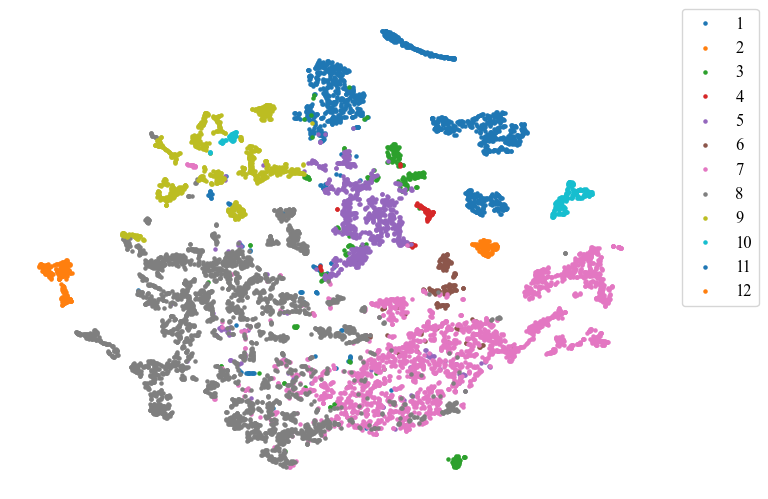

In [12]:
from sklearn.manifold import TSNE
tsne = TSNE()

out = tsne.fit_transform(list_output)
fig, ax = plt.subplots()
ax.set_axis_off()
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# fig.set_size_inches(label.shape[1] * scale / dpi, label.shape[0] * scale / dpi)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

label = ["Broccoli-weeds-1","Broccoli-weeds-2","Fallow","Fallow-rough-plow",
         "Fallow-smooth","Stubble","Celery","Grapes-untrained",
         "Soil-senesced-develop","Corn-weeds","Lettuce-4wk","Lettuce-5wk",
         "Lettuce-6wk","Lettuce-7wk","Vinyard-untrained",
         "Vinyard-vertical-trellis"]
for i in range(class_num):
    indices = list_target  == i
    x, y = out[indices].T
    # plt.scatter(x, y, s=5, label=label[i])
    plt.scatter(x, y, s=5, label=str(i+1))
plt.legend(loc=2,bbox_to_anchor=(1.05,1.0),borderaxespad = 0., fontsize=12)
plt.savefig(args.result_dir  + '/tsneFull' + '.png', dpi=400, bbox_inches="tight")

# 线性测试

In [13]:
head = model.FDGC_head(in_dim=args.feature_dim, class_num=class_num).to(args.device)

args.resume = os.path.join(args.result_dir, "joint_model_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    head.load_state_dict(checkpoint['head'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

params = list(net.parameters()) + list(head.parameters())
optimizer = torch.optim.Adam(params, lr=3e-4)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.MultiStepLR(
                optimizer, milestones=[args.epochs // 2, 
                (5 * args.epochs) // 6], gamma=0.1)

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/10-18-14-24-vit_D_super/joint_model_loss.pth


In [14]:
for name, param in net.named_parameters():
    param.requires_grad = False
    # print(param.requires_grad)      

In [15]:
def train(net, head, max_epoch, memory_loader, test_loader, criterion, optimizer, scheduler):
  best_loss = 9999
  best_acc = 0
  train_losses = []

  for epoch in range(1, max_epoch+1):
    net.train()
    head.train()
    test_preds = []
    train_correct = 0
    test_correct = 0
    tic1 = time.time()
    
    for data, _, target in memory_loader:
      target = target -1
      data = data.to(args.device)
      target = target.to(args.device)
      optimizer.zero_grad()
      output = head(net(data))
      loss = criterion(output, target)
      loss.backward()
      optimizer.step()
      pred = output.data.max(1, keepdim=True)[1]
      train_correct += pred.eq(target.data.view_as(pred)).sum()

    scheduler.step()
    train_losses.append(loss.cpu().detach().item())
    train_accuracy = 100. * train_correct / len(memory_loader.dataset)
    training_time = time.time() - tic1

    # validation 
    tic2 = time.time()
    if epoch % args.log_interval == 0:
      net.eval()
      head.eval()
      with torch.no_grad():
        for data, _, target in test_loader:
          target = target - 1 
          data, target= data.to(args.device), target.to(args.device)
          output = head(net(data))
          test_pred = output.data.max(1, keepdim=True)[1]
          test_correct += test_pred.eq(target.data.view_as(test_pred)).sum()
          test_label = torch.argmax(output, dim=1)
          test_preds.append(test_label.cpu().numpy().tolist())
      test_accuracy = 100. * test_correct / len(test_loader.dataset)
    

      if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({"epoch": epoch,
                    "model": net.state_dict(),
                    "head": head.state_dict(),
                    "optimizer": optimizer.state_dict()},
                    args.result_dir + "/best_model_loss.pth")
        print("save best loss weights at epoch", epoch)

      # 按照道理说，这里应该用train_acc, 但是为了精度，我选择 test_acc
      if test_accuracy.item() > best_acc:
        best_acc = test_accuracy.item()
        torch.save({"epoch": epoch,
                    "model": net.state_dict(),
                    "head": head.state_dict(),
                    "optimizer": optimizer.state_dict()},
                    args.result_dir + "/best_model_acc.pth")
        print("save best acc weights at epoch", epoch)
    test_time = time.time() - tic2

    print("epoch", epoch,
          "loss", round(loss.item(), 6), 
          "train_correct", round(test_correct.item(), 4), 
          "test_accuracy", round(test_accuracy.item(), 4))

    # with open(os.path.join(args.result_dir, "linear.csv"), 'a+', encoding='gbk') as f:
    #     row=[["epoch", epoch, 
    #           "train num", args.train_num,
    #             "loss", round(loss.item(), 4), 
    #             "train acc", round(train_accuracy.item(), 4),
    #             "test acc", round(test_accuracy.item(), 4),
    #             "training time", round(training_time, 4),
    #             "test time", round(test_time, 4)
    #             ]]
    #     write=csv.writer(f)
    #     for i in range(len(row)):
    #         write.writerow(row[i])
  return train_losses, train_accuracy

train_losses, train_accuracy = train(net, head, args.tune_epochs, 
                memory_loader, test_loader, criterion, optimizer, scheduler)

save best loss weights at epoch 1
save best acc weights at epoch 1
epoch 1 loss 0.000135 train_correct 7966 test_accuracy 80.7256
save best loss weights at epoch 2
save best acc weights at epoch 2
epoch 2 loss 9.8e-05 train_correct 7967 test_accuracy 80.7357
epoch 3 loss 0.000149 train_correct 7935 test_accuracy 80.4114
save best loss weights at epoch 4
epoch 4 loss 4.2e-05 train_correct 7910 test_accuracy 80.1581
epoch 5 loss 7.6e-05 train_correct 7915 test_accuracy 80.2088
epoch 6 loss 4.2e-05 train_correct 7797 test_accuracy 79.013
epoch 7 loss 6.7e-05 train_correct 7896 test_accuracy 80.0162
save best loss weights at epoch 8
epoch 8 loss 2.5e-05 train_correct 7837 test_accuracy 79.4183
save best acc weights at epoch 9
epoch 9 loss 5.3e-05 train_correct 7978 test_accuracy 80.8472
epoch 10 loss 4.6e-05 train_correct 7911 test_accuracy 80.1682


In [16]:
args.resume = os.path.join(args.result_dir, "best_model_acc.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['model'], strict=False)
    head.load_state_dict(checkpoint['head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0
    
test_losses, test_preds, correct, targets = \
    tester.linear_test(net, head, criterion, test_loader, args)
classification, kappa = tester.get_results(test_preds, targets)

# print(KNNOA)
with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["epoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        # "total_time", round(total_time, 2)
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/10-18-14-24-vit_D_super/best_model_acc.pth epoch 10
Accuracy: 7978/9868 (80.85%)

